Загрузка набора данных

In [6]:
import pandas as pd

data = pd.read_csv("data/merged_dataset.csv")

data.predicted_sentiment

0       POSITIVE
1       POSITIVE
2       POSITIVE
3       POSITIVE
4       POSITIVE
          ...   
7567     NEUTRAL
7568     NEUTRAL
7569     NEUTRAL
7570     NEUTRAL
7571     NEUTRAL
Name: predicted_sentiment, Length: 7572, dtype: object

Преобразование категориального признака в несколько бинарных признаков
Унитарное кодирование признака Сентимент (predicted_sentiment)
Кодирование

In [7]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

encoder = OneHotEncoder(sparse_output=False)

encoded_values = encoder.fit_transform(data[["predicted_sentiment"]])

encoded_columns = encoder.get_feature_names_out(["predicted_sentiment"])

encoded_values_df = pd.DataFrame(encoded_values, columns=encoded_columns)

encoded_values_df


,predicted_sentiment_NEGATIVE,predicted_sentiment_NEUTRAL,predicted_sentiment_POSITIVE
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
7567,0.0,1.0,0.0
7568,0.0,1.0,0.0
7569,0.0,1.0,0.0
7570,0.0,1.0,0.0


Добавление признаков в исходный Dataframe

In [8]:
data = pd.concat([data, encoded_values_df], axis=1)

data

,review,clean_review,predicted_sentiment,clinic,doctor,service,sentiment_score,predicted_sentiment_NEGATIVE,predicted_sentiment_NEUTRAL,predicted_sentiment_POSITIVE
0,"Обратились в поликлинику, специалист Сергей Ви...",обратиться поликлиника специалист сергей вик...,POSITIVE,1,0,0,0.981365,0.0,0.0,1.0
1,Обратился в эту клинику и был приятно удивлен ...,обратиться клиника приятно удивлённый качество...,POSITIVE,1,1,1,0.981429,0.0,0.0,1.0
2,Прийти на прием к проктологу - это ведь не к т...,прийти приём проктолог это терапевт насморк...,POSITIVE,0,1,0,0.981413,0.0,0.0,1.0
3,"От всей души благодарю весь коллектив ""Уро-Про...",весь душа благодарить весь коллектив уро ...,POSITIVE,0,1,0,0.981429,0.0,0.0,1.0
4,Хочу выразить благодарность доктору Можаевой Е...,хотеть выразить благодарность доктор можаевой ...,POSITIVE,0,1,0,0.981412,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
7567,Издеваются над людьми! Держат в заложниках эмб...,NaN,NEUTRAL,0,0,0,NaN,0.0,1.0,0.0
7568,Добрый день\nСегодня я обратилась в эту клиник...,NaN,NEUTRAL,0,0,0,NaN,0.0,1.0,0.0
7569,"Говорят, основываясь на данных, в которых толь...",NaN,NEUTRAL,0,0,0,NaN,0.0,1.0,0.0
7570,"Была на приёме ,врач не опытный ,не воспитанны...",NaN,NEUTRAL,0,1,0,NaN,0.0,1.0,0.0


Дискретизация признаков
Равномерное разделение данных на 3 группы

In [14]:
labels = [
    "низкий уровень",
    "средний уровень", 
    "высокий уровень"
]
num_bins = 3

In [15]:
hist1, bins1 = np.histogram(data["sentiment_score"].fillna(data["sentiment_score"].median()), bins=num_bins)
bins1, hist1

(array([0.2139475 , 0.47231412, 0.73068073, 0.98904735]),
 array([ 683,  475, 6414]))

In [16]:
pd.concat([data["sentiment_score"], pd.cut(data["sentiment_score"], list(bins1))], axis=1).head(20)

,sentiment_score,sentiment_score
0,0.981365,"(0.731, 0.989]"
1,0.981429,"(0.731, 0.989]"
2,0.981413,"(0.731, 0.989]"
3,0.981429,"(0.731, 0.989]"
4,0.981412,"(0.731, 0.989]"
5,0.981396,"(0.731, 0.989]"
6,0.957458,"(0.731, 0.989]"
7,0.981374,"(0.731, 0.989]"
8,0.981380,"(0.731, 0.989]"
9,0.751587,"(0.731, 0.989]"


In [17]:
pd.concat([data["sentiment_score"], pd.cut(data["sentiment_score"], list(bins1), labels=labels)], axis=1).head(20)

,sentiment_score,sentiment_score
0,0.981365,высокий уровень
1,0.981429,высокий уровень
2,0.981413,высокий уровень
3,0.981429,высокий уровень
4,0.981412,высокий уровень
5,0.981396,высокий уровень
6,0.957458,высокий уровень
7,0.981374,высокий уровень
8,0.981380,высокий уровень
9,0.751587,высокий уровень


Равномерное разделение данных на 3 группы c установкой собственной границы диапазона значений (от 0 до 100)

In [19]:
bins2 = np.linspace(0, 1, 4)
tmp_bins2 = np.digitize(data["sentiment_score"].fillna(data["sentiment_score"].median()), bins2)
hist2 = np.bincount(tmp_bins2 - 1)
bins2, hist2

(array([0.        , 0.33333333, 0.66666667, 1.        ]),
 array([ 189,  913, 6470]))

In [20]:
pd.concat([data["sentiment_score"], pd.cut(data["sentiment_score"], list(bins2))], axis=1).head(20)

,sentiment_score,sentiment_score
0,0.981365,"(0.667, 1.0]"
1,0.981429,"(0.667, 1.0]"
2,0.981413,"(0.667, 1.0]"
3,0.981429,"(0.667, 1.0]"
4,0.981412,"(0.667, 1.0]"
5,0.981396,"(0.667, 1.0]"
6,0.957458,"(0.667, 1.0]"
7,0.981374,"(0.667, 1.0]"
8,0.981380,"(0.667, 1.0]"
9,0.751587,"(0.667, 1.0]"


In [21]:
pd.concat([data["sentiment_score"], pd.cut(data["sentiment_score"], list(bins2), labels=labels)], axis=1).head(20)

,sentiment_score,sentiment_score
0,0.981365,высокий уровень
1,0.981429,высокий уровень
2,0.981413,высокий уровень
3,0.981429,высокий уровень
4,0.981412,высокий уровень
5,0.981396,высокий уровень
6,0.957458,высокий уровень
7,0.981374,высокий уровень
8,0.981380,высокий уровень
9,0.751587,высокий уровень


Равномерное разделение данных на 3 группы c установкой собственных интервалов (0 - 0.33, 0.34 - 0.6, 0.61 - 1)

In [22]:
hist3, bins3 = np.histogram(
    data["sentiment_score"].fillna(data["sentiment_score"].median()), bins=[0, 0.34, 0.6, 1]
)
bins3, hist3

(array([0.  , 0.34, 0.6 , 1.  ]), array([ 210,  799, 6563]))

In [23]:
pd.concat([data["sentiment_score"], pd.cut(data["sentiment_score"], list(bins3))], axis=1).head(20)

,sentiment_score,sentiment_score
0,0.981365,"(0.6, 1.0]"
1,0.981429,"(0.6, 1.0]"
2,0.981413,"(0.6, 1.0]"
3,0.981429,"(0.6, 1.0]"
4,0.981412,"(0.6, 1.0]"
5,0.981396,"(0.6, 1.0]"
6,0.957458,"(0.6, 1.0]"
7,0.981374,"(0.6, 1.0]"
8,0.981380,"(0.6, 1.0]"
9,0.751587,"(0.6, 1.0]"


In [24]:
pd.concat([data["sentiment_score"], pd.cut(data["sentiment_score"], list(bins3), labels=labels)], axis=1).head(20)

,sentiment_score,sentiment_score
0,0.981365,высокий уровень
1,0.981429,высокий уровень
2,0.981413,высокий уровень
3,0.981429,высокий уровень
4,0.981412,высокий уровень
5,0.981396,высокий уровень
6,0.957458,высокий уровень
7,0.981374,высокий уровень
8,0.981380,высокий уровень
9,0.751587,высокий уровень


Квантильное разделение данных на 3 группы

In [25]:
pd.concat([data["sentiment_score"], pd.qcut(data["sentiment_score"], q=3, labels=False)], axis=1).head(20)

,sentiment_score,sentiment_score
0,0.981365,2.0
1,0.981429,2.0
2,0.981413,2.0
3,0.981429,2.0
4,0.981412,2.0
5,0.981396,2.0
6,0.957458,1.0
7,0.981374,2.0
8,0.981380,2.0
9,0.751587,0.0


In [26]:
pd.concat([data["sentiment_score"], pd.qcut(data["sentiment_score"], q=3, labels=labels)], axis=1).head(20)

,sentiment_score,sentiment_score
0,0.981365,высокий уровень
1,0.981429,высокий уровень
2,0.981413,высокий уровень
3,0.981429,высокий уровень
4,0.981412,высокий уровень
5,0.981396,высокий уровень
6,0.957458,средний уровень
7,0.981374,высокий уровень
8,0.981380,высокий уровень
9,0.751587,низкий уровень


Отсечение значений признаков
Определение выбросов с помощью boxplot

<Axes: >

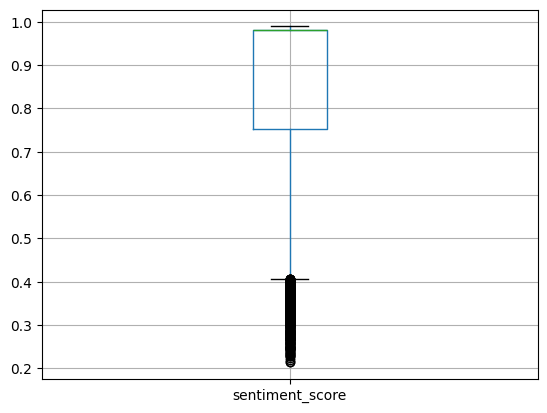

In [27]:
data.boxplot(column="sentiment_score")

Отсечение данных для признака уровень сентимента, значение которых меньше 0.4

In [28]:
data_norm = data.copy()

data_norm["sentiment_score_clip"] = data["sentiment_score"].clip(0.4, 1);

data_norm[data_norm["sentiment_score"] < 0.4][["review", "predicted_sentiment", "sentiment_score", "sentiment_score_clip"]]

,review,predicted_sentiment,sentiment_score,sentiment_score_clip
1008,"Была в этой больнице. Медсестры не шевелятся, ...",NEUTRAL,0.399527,0.4
1038,"В общем-то, сами палаты вполне нормальные, чис...",POSITIVE,0.387074,0.4
1835,Сплошная коммерция. Делал холодноплазменную ну...,NEUTRAL,0.383208,0.4
2168,"Понравилось, какие тут косметологи. Первый раз...",NEGATIVE,0.354103,0.4
2218,В гинекологическом кабинете лучше бы ширмочку ...,POSITIVE,0.386660,0.4
...,...,...,...,...
6021,"Недружелюбно; Вас с нетерпеливо прерывают, есл...",NEGATIVE,0.379831,0.4
6022,"Не обязательно использует антибиотики, имеет о...",NEGATIVE,0.339744,0.4
6025,Я позвонил на практике от острой боли в ногах....,NEGATIVE,0.374087,0.4
6026,"Я был с доктором Шомбург, потому что доктора, ...",NEGATIVE,0.333881,0.4


Винсоризация признака Уровень сентимента

In [33]:
from scipy.stats.mstats import winsorize

print(data_norm["sentiment_score"].quantile(q=0.95))

data_norm["sentiment_score_winsorize"] = winsorize(
    data_norm["sentiment_score"].fillna(data_norm["sentiment_score"].mean()), (0.05, 0.05), inplace=False
)

data_norm[data_norm["sentiment_score"] < 0.4][["review", "predicted_sentiment", "sentiment_score", "sentiment_score_winsorize"]]

0.9814246475696563


,review,predicted_sentiment,sentiment_score,sentiment_score_winsorize
1008,"Была в этой больнице. Медсестры не шевелятся, ...",NEUTRAL,0.399527,0.399527
1038,"В общем-то, сами палаты вполне нормальные, чис...",POSITIVE,0.387074,0.391910
1835,Сплошная коммерция. Делал холодноплазменную ну...,NEUTRAL,0.383208,0.391910
2168,"Понравилось, какие тут косметологи. Первый раз...",NEGATIVE,0.354103,0.391910
2218,В гинекологическом кабинете лучше бы ширмочку ...,POSITIVE,0.386660,0.391910
...,...,...,...,...
6021,"Недружелюбно; Вас с нетерпеливо прерывают, есл...",NEGATIVE,0.379831,0.391910
6022,"Не обязательно использует антибиотики, имеет о...",NEGATIVE,0.339744,0.391910
6025,Я позвонил на практике от острой боли в ногах....,NEGATIVE,0.374087,0.391910
6026,"Я был с доктором Шомбург, потому что доктора, ...",NEGATIVE,0.333881,0.391910


Нормализация значений

In [34]:
from sklearn import preprocessing

min_max_scaler = preprocessing.MinMaxScaler()

min_max_scaler_2 = preprocessing.MinMaxScaler(feature_range=(-1, 1))

data_norm["sentiment_score_norm"] = min_max_scaler.fit_transform(
    data_norm["sentiment_score"].to_numpy().reshape(-1, 1)
).reshape(data_norm["sentiment_score"].shape)

data_norm["sentiment_score_clip_norm"] = min_max_scaler.fit_transform(
    data_norm["sentiment_score_clip"].to_numpy().reshape(-1, 1)
).reshape(data_norm["sentiment_score"].shape)

data_norm["sentiment_score_wonsorize_norm"] = min_max_scaler.fit_transform(
    data_norm["sentiment_score_winsorize"].to_numpy().reshape(-1, 1)
).reshape(data_norm["sentiment_score"].shape)

data_norm["sentiment_score_wonsorize_norm2"] = min_max_scaler_2.fit_transform(
    data_norm["sentiment_score_winsorize"].to_numpy().reshape(-1, 1)
).reshape(data_norm["sentiment_score"].shape)

data_norm[
    ["review", "predicted_sentiment", "sentiment_score", "sentiment_score_norm", "sentiment_score_wonsorize_norm", "sentiment_score_wonsorize_norm2"]
].head(20)

,review,predicted_sentiment,sentiment_score,sentiment_score_norm,sentiment_score_wonsorize_norm,sentiment_score_wonsorize_norm2
0,"Обратились в поликлинику, специалист Сергей Ви...",POSITIVE,0.981365,0.990089,0.999905,0.999810
1,Обратился в эту клинику и был приятно удивлен ...,POSITIVE,0.981429,0.990171,1.000000,1.000000
2,Прийти на прием к проктологу - это ведь не к т...,POSITIVE,0.981413,0.990151,0.999987,0.999973
3,"От всей души благодарю весь коллектив ""Уро-Про...",POSITIVE,0.981429,0.990171,1.000000,1.000000
4,Хочу выразить благодарность доктору Можаевой Е...,POSITIVE,0.981412,0.990149,0.999984,0.999968
5,"Посетила клинику ""УРО-ПРО"" впервые и осталась ...",POSITIVE,0.981396,0.990128,0.999957,0.999913
6,Обращалась к Звягину Сергею Викторовичу. Очень...,POSITIVE,0.957458,0.959245,0.959350,0.918700
7,Сегодня (12.09.2022) прошла колоноскопию под с...,POSITIVE,0.981374,0.990100,0.999920,0.999839
8,"Вовремя, оперативно. Вежливый персонал. Внимат...",POSITIVE,0.981380,0.990108,0.999930,0.999859
9,"Я считаю, что такое лечение моего мужа со стор...",NEGATIVE,0.751587,0.693639,0.610128,0.220255


Стандартизация значений

In [35]:
from sklearn import preprocessing

stndart_scaler = preprocessing.StandardScaler()

data_norm["sentiment_score_stand"] = stndart_scaler.fit_transform(
    data_norm["sentiment_score"].to_numpy().reshape(-1, 1)
).reshape(data_norm["sentiment_score"].shape)

data_norm["sentiment_score_clip_stand"] = stndart_scaler.fit_transform(
    data_norm["sentiment_score_clip"].to_numpy().reshape(-1, 1)
).reshape(data_norm["sentiment_score"].shape)

data_norm["sentiment_score_winsorize_stand"] = stndart_scaler.fit_transform(
    data_norm["sentiment_score_winsorize"].to_numpy().reshape(-1, 1)
).reshape(data_norm["sentiment_score"].shape)

data_norm[["review", "predicted_sentiment", "sentiment_score", "sentiment_score_stand", "sentiment_score_clip_stand", "sentiment_score_winsorize_stand"]].head(20)

,review,predicted_sentiment,sentiment_score,sentiment_score_stand,sentiment_score_clip_stand,sentiment_score_winsorize_stand
0,"Обратились в поликлинику, специалист Сергей Ви...",POSITIVE,0.981365,0.638265,0.650962,0.732959
1,Обратился в эту клинику и был приятно удивлен ...,POSITIVE,0.981429,0.638564,0.651278,0.733270
2,Прийти на прием к проктологу - это ведь не к т...,POSITIVE,0.981413,0.638491,0.651201,0.733226
3,"От всей души благодарю весь коллектив ""Уро-Про...",POSITIVE,0.981429,0.638563,0.651278,0.733270
4,Хочу выразить благодарность доктору Можаевой Е...,POSITIVE,0.981412,0.638484,0.651194,0.733217
5,"Посетила клинику ""УРО-ПРО"" впервые и осталась ...",POSITIVE,0.981396,0.638408,0.651113,0.733128
6,Обращалась к Звягину Сергею Викторовичу. Очень...,POSITIVE,0.957458,0.525783,0.532104,0.600532
7,Сегодня (12.09.2022) прошла колоноскопию под с...,POSITIVE,0.981374,0.638305,0.651005,0.733007
8,"Вовремя, оперативно. Вежливый персонал. Внимат...",POSITIVE,0.981380,0.638333,0.651034,0.733040
9,"Я считаю, что такое лечение моего мужа со стор...",NEGATIVE,0.751587,-0.442812,-0.491397,-0.539819
